# 3. Analysis data from Foot / HeartRate / GPX (location)
1. Read data and do basic analysis   

In [1]:
#basic
import os
import math
from pathlib import Path
from datetime import datetime # datetime

#analysis
import numpy as np
import pandas as pd
import folium # map
from IPython.display import IFrame
#Statistik
import scipy.stats as stats

#plot
import matplotlib.pyplot as plt
import seaborn as sns

1. Read data
We have 5 data files in `.csv` format:  
- One file corresponds to the date `2025/11/16`, surface type `Grass`, and subject `P06P`.  
- The other four files correspond to the date `2025/11/17`, surface types `Asphalt`, `Grass`, `Forest`, and `Sand`, and subject `S07`.

We will read these data files and load them into a single DataFrame.

In [2]:
# read data form
input_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/processed/Data frame from foot heart GPX"
# name of File as csv
os.makedirs(input_path, exist_ok=True)
file_names = [f for f in os.listdir(input_path) if f.endswith(".csv")]

name_of_dataframe = []
for i in range(len(file_names)):
    name_df = file_names[i]
    name = file_names[i].replace(".csv","")
    name_of_dataframe.append(name)
    path = f"{input_path}/{name_df}"
    data = pd.read_csv(path)
    globals()[name] = data

C:\Users\user\Oracel19c\admin\orcl\Temp\ipykernel_11564\4260495585.py:13: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\user\Oracel19c\admin\orcl\Temp\ipykernel_11564\4260495585.py:13: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\user\Oracel19c\admin\orcl\Temp\ipykernel_11564\4260495585.py:13: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\user\Oracel19c\admin\orcl\Temp\ipykernel_11564\4260495585.py:13: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\user\Oracel19c\admin\orcl\Temp\ipykernel_11564\4260495585.py:13: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.

In [3]:
name_of_dataframe

['Asphalt_S07_01_341_Date_2025_11_17_Time_10_09_36',
 'Forest_S07_02_492_Date_2025_11_17_Time_09_53_52',
 'Grass_P06P_01_845_Date_2025_11_16_Time_14_46_47',
 'Grass_S07_01_980_Date_2025_11_17_Time_09_27_24',
 'Sand__S07_01_073_Date_2025_11_17_Time_09_15_09']

# fillna
The DataFrames contain columns with `null` values due to timing mismatches:  
- Foot force data is sampled at **0.01-second** intervals.  
- Heart rate (`HR`) and location data (e.g., `latitude`, `longitude`, `elevation`) are sampled at **1-second** intervals.

To align the data, we fill the `null` values using the **`interpolate()`** method. This performs linear interpolation such that:
- If the first valid value is `109` and the next is `111`, the 99 intermediate values (corresponding to 0.01-second steps) are filled **in ascending order** from `109` to `111`.  
- Conversely, if values decrease (e.g., from `111` to `109`), the intermediate values are filled **in descending order**.

The interpolated columns include:  
`HR (bpm)`, `Speed (km/h)`, `Cadence`, `Distances (m)`, `latitude`, `longitude`, `elevation`.

In [ ]:
output_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/processed/Data frame from foot heart GPX fillna"
for i in name_of_dataframe:
    df = globals()[i].copy()
    df[df.columns[16:]] = df[df.columns[16:]].interpolate(method='polynomial', order=2)
    # df['Speed (km/h)'] = df['Speed (km/h)'].abs()
    # df['Cadence'] = df['Cadence'].abs()
    # df['Distances (m)'] = df['Distances (m)'].abs()
    globals()[i] = df
    output_file = os.path.join(output_path, f"{i}.csv")
    globals()[i].to_csv(output_file, index=False) 



C:\Users\user\Oracel19c\admin\orcl\Temp\ipykernel_11564\3517746399.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[df.columns[16:]] = df[df.columns[16:]].interpolate(method='polynomial', order=2)


In [5]:
input_path = r"C:/Users/user/Desktop/Fatemeh/Analysis_Data/data/processed/Data frame from foot heart GPX fillna"
# name of File as csv
os.makedirs(input_path, exist_ok=True)
file_names = [f for f in os.listdir(input_path) if f.endswith(".csv")]

name_of_dataframe = []
for i in range(len(file_names)):
    name_df = file_names[i]
    name = file_names[i].replace(".csv","")
    name_of_dataframe.append(name)
    path = f"{input_path}/{name_df}"
    data = pd.read_csv(path)
    globals()[name] = data

C:\Users\user\Oracel19c\admin\orcl\Temp\ipykernel_12556\2609922777.py:12: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\user\Oracel19c\admin\orcl\Temp\ipykernel_12556\2609922777.py:12: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\user\Oracel19c\admin\orcl\Temp\ipykernel_12556\2609922777.py:12: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\user\Oracel19c\admin\orcl\Temp\ipykernel_12556\2609922777.py:12: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)
C:\Users\user\Oracel19c\admin\orcl\Temp\ipykernel_12556\2609922777.py:12: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.

# Q1 :
The highest speed on 2025/11/17 on Asphalt, Forest, Grass, and Sand surfaces is what?   
Calculation method: What is the average of the top 1% of speeds?   
| Date       | Foundation | Speed (km/h) |
|------------|------------|---------------|
| 17-11-2025 | Asphalt    | 15.505        |
| 17-11-2025 | Forest     | 16.462        |
| 17-11-2025 | Grass      | 11.817        |
| 17-11-2025 | Sand       | 14.337        |

Calculation method: What is the average of the top 10% of speeds?   
| Date       | Foundation | Speed (km/h) |
|------------|------------|---------------|
| 17-11-2025 | Asphalt    | 14.829        |
| 17-11-2025 | Forest     | 14.672        |
| 17-11-2025 | Grass      | 10.846        |
| 17-11-2025 | Sand       | 13.654        |

In [6]:
name_17 =  [name_of_dataframe[i] for i in [0, 1, 3, 4]]
for i in name_17:
    df = globals()[i].copy()
    sorted_speeds = df["Speed (km/h)"].sort_values(ascending=False)
    top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * 0.10))
    mean_top_1_percent = top_1_percent.mean()
    print(f"Date: {df["value"].iloc[2]}  foundation: {df["foundation"].iloc[0]}  speed(km/h): {mean_top_1_percent}")



Date: 17-11-2025  foundation: Asphalt  speed(km/h): 14.829613449274571
Date: 17-11-2025  foundation: Forest  speed(km/h): 14.672986153101078
Date: 17-11-2025  foundation: Grass  speed(km/h): 10.846453299447822
Date: 17-11-2025  foundation: Sand  speed(km/h): 13.65484414761767


In [ ]:
name_17 =  [name_of_dataframe[i] for i in [0, 1, 3, 4]]
loc_plot = 1
for i in name_17:
    df = globals()[i].copy()
    
    sorted_speeds = df["Speed (km/h)"].sort_values(ascending=False)
    top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * 0.10))
    mean_top_1_percent = top_1_percent.mean()
    print(f"Date: {df["value"].iloc[2]}  foundation: {df["foundation"].iloc[0]}  speed(km/h): {mean_top_1_percent}")



In [29]:
df.head(10)

,type name,value,foundation,Date,Start_Time,Time_Running,Time_x,L_Heel,L_Midfoot,L_Forefoot,...,Pace (min/km),Cadence,Altitude (m),Stride length (m),Distances (m),Temperatures (C),Power (W),latitude,longitude,elevation
0,Name,Maximilian Stasica,Asphalt,2025-11-17,10:09:36,10:09:36.00,0.00,160.65,0.0,630.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sport,RUNNING,Asphalt,2025-11-17,10:09:36,10:09:36.01,0.01,148.05,0.0,642.60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Date,17-11-2025,Asphalt,2025-11-17,10:09:36,10:09:36.02,0.02,129.15,0.0,661.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Start time,11:10:27,Asphalt,2025-11-17,10:09:36,10:09:36.03,0.03,113.40,0.0,677.25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Duration,00:06:55,Asphalt,2025-11-17,10:09:36,10:09:36.04,0.04,94.50,0.0,686.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Total distance (km),1.25,Asphalt,2025-11-17,10:09:36,10:09:36.05,0.05,81.90,0.0,699.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Average heart rate (bpm),161,Asphalt,2025-11-17,10:09:36,10:09:36.06,0.06,72.45,0.0,711.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Average speed (km/h),10.8,Asphalt,2025-11-17,10:09:36,10:09:36.07,0.07,63.00,0.0,724.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Max speed (km/h),15.3,Asphalt,2025-11-17,10:09:36,10:09:36.08,0.08,53.55,0.0,737.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Average pace (min/km),05:32,Asphalt,2025-11-17,10:09:36,10:09:36.09,0.09,44.10,0.0,746.55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
name_17

['Asphalt_S07_01_341_Date_2025_11_17_Time_10_09_36',
 'Forest_S07_02_492_Date_2025_11_17_Time_09_53_52',
 'Grass_S07_01_980_Date_2025_11_17_Time_09_27_24',
 'Sand__S07_01_073_Date_2025_11_17_Time_09_15_09']

In [126]:
name_17

['Asphalt_S07_01_341_Date_2025_11_17_Time_10_09_36',
 'Forest_S07_02_492_Date_2025_11_17_Time_09_53_52',
 'Grass_S07_01_980_Date_2025_11_17_Time_09_27_24',
 'Sand__S07_01_073_Date_2025_11_17_Time_09_15_09']

Date: 17-11-2025  foundation: Asphalt  speed(km/h): 13.65484414761767
Date: 17-11-2025  foundation: Forest  speed(km/h): 13.65484414761767
Date: 17-11-2025  foundation: Grass  speed(km/h): 13.65484414761767
Date: 17-11-2025  foundation: Sand  speed(km/h): 13.65484414761767


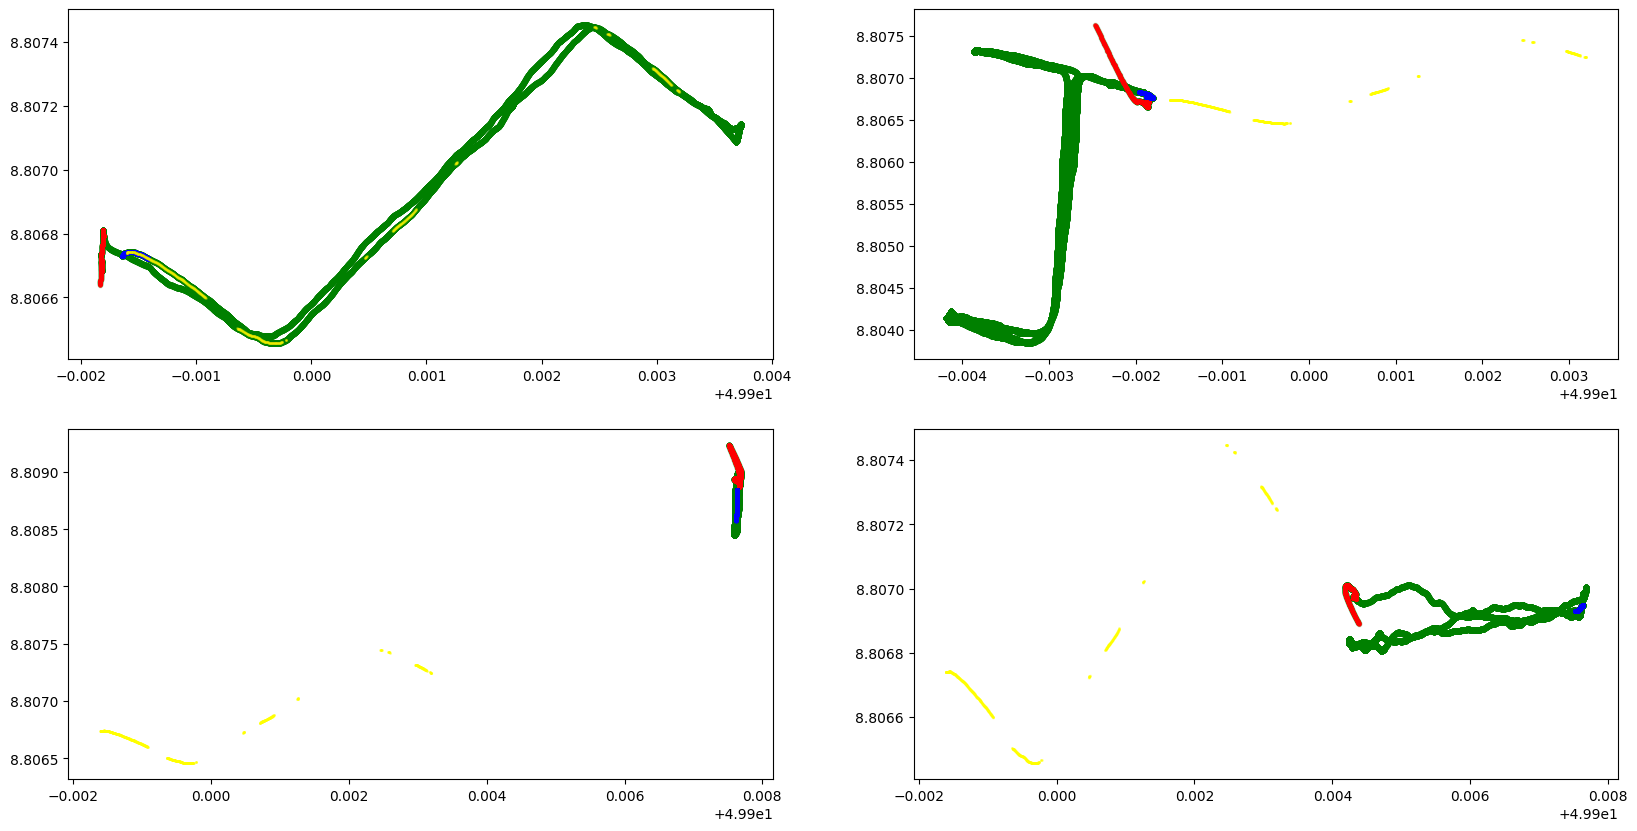

In [128]:
name_17 =  [name_of_dataframe[i] for i in [0, 1, 3, 4]]
loc_plot = 1
plt.figure(figsize=(20,10))
for i in name_17:
    df = globals()[i].copy()
    df_first = df.dropna(subset=["longitude", "latitude"]).head(1000).copy()
    df_end = df.dropna(subset=["longitude", "latitude"]).tail(1000).copy()
    plt.subplot(2,2,loc_plot)
    plt.scatter(df["latitude"], df["longitude"],
            s=10, color="green", alpha=0.2, linestyle='-')
    plt.scatter(df_first["latitude"], df_first["longitude"],
            s=5, color="red", alpha=0.9, linestyle='-')
    plt.scatter(df_end["latitude"], df_end["longitude"],
            s=5, color="blue", alpha=0.9, linestyle='-')
    top = 0.10
    sorted_df_speed = df.sort_values(by="Speed (km/h)", ascending=False)
    top_df = sorted_speeds.head(int(len(sorted_speeds) * top))
    plt.scatter(top_df["latitude"], top_df["longitude"],
            s=1, color="yellow", alpha=0.05, linestyle='-')
    mead_speed = top_df["Speed (km/h)"].mean()
    print(f"Date: {df["value"].iloc[2]}  foundation: {df["foundation"].iloc[0]}  speed(km/h): {mean_top_1_percent}")
    loc_plot+=1








# df = globals()[name_17[0]].copy()
# df_first = df.dropna(subset=["longitude", "latitude"]).head(1000).copy()
# df_end = df.dropna(subset=["longitude", "latitude"]).tail(1000).copy()

# plt.figure(figsize=(20,10))
# plt.subplot(2,2,1)
# plt.scatter(df["latitude"], df["longitude"],
#             s=10, color="green", alpha=0.2, linestyle='-')

# plt.scatter(df_first["latitude"], df_first["longitude"],
#             s=5, color="red", alpha=0.9, linestyle='-')

# plt.scatter(df_end["latitude"], df_end["longitude"],
#             s=5, color="blue", alpha=0.9, linestyle='-')

# top = 0.10
# sorted_df_speed = df.sort_values(by="Speed (km/h)", ascending=False)
# top_df = sorted_speeds.head(int(len(sorted_speeds) * top))

# plt.scatter(top_df["latitude"], top_df["longitude"],
#             s=1, color="yellow", alpha=0.05, linestyle='-')



In [123]:
top_df["Speed (km/h)"].mean()

np.float64(14.829613449274571)

<Axes: xlabel='latitude', ylabel='longitude'>

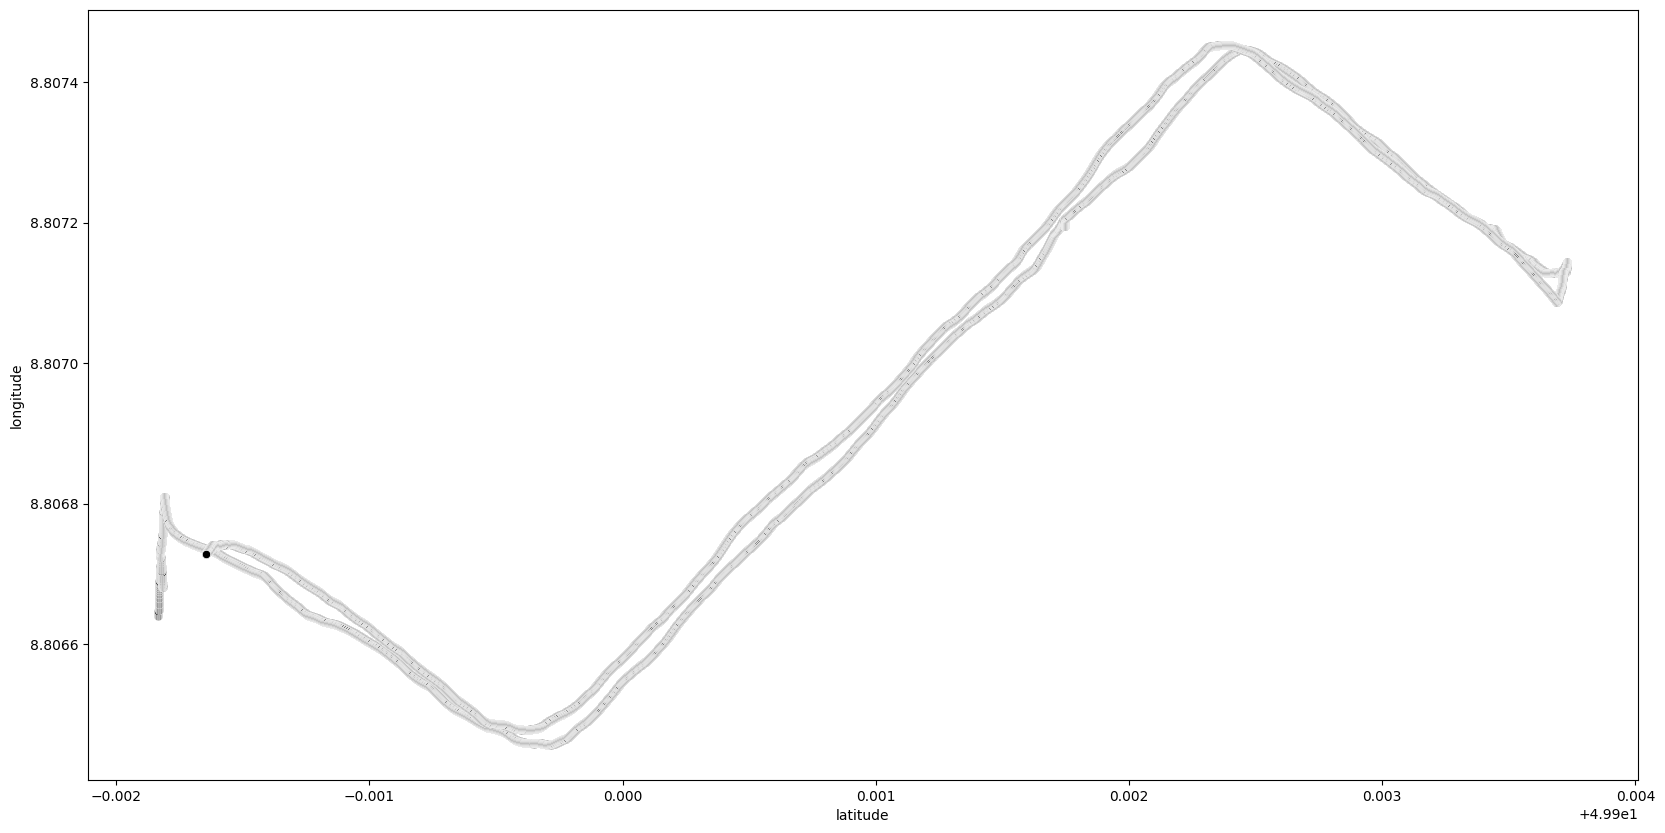

In [84]:
name_17 =  [name_of_dataframe[i] for i in [0, 1, 3, 4]]
df = globals()[name_17[0]].copy()
df_first = df.dropna(subset=["longitude", "latitude"]).head(1000).copy()
df_end = df.dropna(subset=["longitude", "latitude"]).tail(1000).copy()

plt.figure(figsize=(20,10))

sns.scatterplot(
    data = df,
    x="latitude",
    y="longitude",
    color="black"
)


# sns.scatterplot(
#     data=df,
#     x="latitude",
#     y="longitude",
#     color="green"
# )

# sns.scatterplot(
#     data=df_first,
#     x="latitude",
#     y="longitude",
#     color="red",
#     alpha=0.9
# )

# sns.scatterplot(
#     data=df_end,
#     x="latitude",
#     y="longitude",
#     color="blue",
#     alpha=0.9
# )
# top = 0.10
# sorted_df_speed = df.sort_values(by="Speed (km/h)", ascending=False)
# top_df = sorted_speeds.head(int(len(sorted_speeds) * top))

# sns.scatterplot(
#     data=top_df,
#     x="latitude",
#     y="longitude",
#     color="gold",
#     alpha=0.9
# )



# Q2:
What is the highest heart rate (HR) on **2025/11/17** on the surfaces **Asphalt, Forest, Grass**, and **Sand**?  
**Calculation method**: the average of the top **1%** of HR values.   
The column `HR (bpm)` in your dataset stands for **Heart Rate**, measured in **beats per minute (bpm)**. This variable indicates how many times the person's heart beats per minute.   
HR stands for Heart Rate.  
bpm stands for beats per minute, meaning the number of heartbeats per minute.  
This value directly reflects the individual's cardiovascular activity during various tasks (in this case: walking or moving on different surfaces).
| HR (bpm) | General Interpretation |
|----------|------------------------|
| < 60     | Bradycardia (slow heart rate). May be normal in athletes, but can indicate a cardiac issue in other individuals. |
| 60 – 100 | Normal resting range for healthy adults. |
| 100 – 140| Light to moderate activity (e.g., brisk walking or stair climbing). |
| 140 – 180+| Intense exercise (e.g., running or vigorous activity). Varies depending on age and physical fitness level. |
| > 200    | Typically occurs in young individuals during maximal exertion; may indicate tachycardia in certain contexts. |

### Result 1%

| Date       | Foundation | HR (bpm) |
|------------|------------|----------|
| 17-11-2025 | Asphalt    | 175.05   |
| 17-11-2025 | Forest     | 180.05   |
| 17-11-2025 | Grass      | 159.35   |
| 17-11-2025 | Sand       | 164.90   |

### Result 10%
| Date       | Foundation | HR (bpm) |
|------------|------------|----------|
| 17-11-2025 | Asphalt    | 174.43   |
| 17-11-2025 | Forest     | 176.37   |
| 17-11-2025 | Grass      | 157.88   |
| 17-11-2025 | Sand       | 160.69   |

In [160]:
name_17 =  [name_of_dataframe[i] for i in [0, 1, 3, 4]]
for i in name_17:
    df = globals()[i].copy()
    sorted_speeds = df["HR (bpm)"].sort_values(ascending=False)
    top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * 0.10))
    mean_top_1_percent = top_1_percent.mean()
    print(f"Date: {df["value"].iloc[2]}  foundation: {df["foundation"].iloc[0]}  HR (bpm): {mean_top_1_percent}")



Date: 17-11-2025  foundation: Asphalt  HR (bpm): 174.42743442650806
Date: 17-11-2025  foundation: Forest  HR (bpm): 176.3724545860722
Date: 17-11-2025  foundation: Grass  HR (bpm): 157.88075912954565
Date: 17-11-2025  foundation: Sand  HR (bpm): 160.68760675587004


# Q3:
What is the highest **Force** value on **2025/11/17** on the surfaces **Asphalt, Forest, Grass**, and **Sand**?  
**Calculation method**: the average of the top **1%** of Force values.   
There are three types of force:  **Heel**, **Midfoot**, and **Forefoot**.  

Forefoot (front of the foot), Midfoot (middle of the foot), and Heel (rear of the foot or heel) forces are commonly measured in biomechanical studies of walking or running using **force plates** or **instrumented insole sensors**. These forces indicate how much load (e.g., in newtons or as a percentage of body weight) is applied to each region of the foot at any given moment.  

| Region     | Location on Foot                          | Primary Function                |
|------------|-------------------------------------------|---------------------------------|
| Heel       | Back of the foot — first contact point in normal walking | Shock absorption               |
| Midfoot    | Midfoot — includes navicular and cuneiform bones | Force transmission and stabilization |
| Forefoot   | Front of the foot — includes metatarsal heads and toes | Propulsion (pushing the body forward) |

In this dataset, **Midfoot** force is not recorded and has a value of zero.   
### for 1%

| Surface  | L_Heel   | L_Midfoot | L_Forefoot | Total_L_Foot | R_Forefoot | R_Midfoot | R_Heel   | Total_R_Foot |
|----------|----------|-----------|------------|--------------|------------|-----------|----------|--------------|
| Asphalt  | 1259.07  | 0.0       | 1636.98    | 1847.17      | 1626.25    | 0.0       | 990.05   | 1738.68      |
| Forest   | 1142.39  | 0.0       | 1620.26    | 1813.60      | 1601.97    | 0.0       | 964.30   | 1721.96      |
| Grass    | 1005.66  | 0.0       | 1570.68    | 1769.64      | 1553.32    | 0.0       | 899.12   | 1728.05      |
| Sand     | 1172.09  | 0.0       | 1649.28    | 1834.55      | 1659.79    | 0.0       | 1044.93  | 1779.86      |

### for 10%
| Surface  | L_Heel  | L_Midfoot | L_Forefoot | Total_L_Foot | R_Forefoot | R_Midfoot | R_Heel  | Total_R_Foot |
|----------|---------|-----------|------------|--------------|------------|-----------|---------|--------------|
| Asphalt  | 704.81  | 0.0       | 1389.81    | 1652.65      | 1395.01    | 0.0       | 594.89  | 1565.96      |
| Forest   | 677.09  | 0.0       | 1411.97    | 1643.26      | 1407.82    | 0.0       | 586.60  | 1568.36      |
| Grass    | 607.39  | 0.0       | 1260.47    | 1526.02      | 1239.75    | 0.0       | 554.75  | 1466.41      |
| Sand     | 702.75  | 0.0       | 1381.88    | 1628.80      | 1399.88    | 0.0       | 646.10  | 1586.98      |

In [161]:
name_17 = [name_of_dataframe[i] for i in [0, 1, 3, 4]]
df_col = globals()[name_17[0]].copy()
col = df_col.columns[7:15].copy()
print(col)
for i in name_17:
    df = globals()[i].copy()
    row_data = []
    for j in col:
        sorted_speeds = df[j].sort_values(ascending=False)
        top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * 0.10))
        mean_top_1_percent = top_1_percent.mean()
        row_data.append(mean_top_1_percent)
    print({df["foundation"].iloc[0]} , list(row_data))



Index(['L_Heel', 'L_Midfoot', 'L_Forefoot', 'Total_L_Foot', 'R_Forefoot',
       'R_Midfoot', 'R_Heel', 'Total_R_Foot'],
      dtype='object')


{'Asphalt'} [np.float64(704.8118298144593), np.float64(0.0), np.float64(1389.8119385796545), np.float64(1652.6525463851565), np.float64(1395.013727873747), np.float64(0.0), np.float64(594.8920132224355), np.float64(1565.958310940499)]
{'Forest'} [np.float64(677.0850374664217), np.float64(0.0), np.float64(1411.9690993920542), np.float64(1643.2636010179558), np.float64(1407.820521702248), np.float64(0.0), np.float64(586.59766718507), np.float64(1568.3623017107307)]
{'Grass'} [np.float64(607.3874712300104), np.float64(0.0), np.float64(1260.472135704678), np.float64(1526.0191197130473), np.float64(1239.7524346136604), np.float64(0.0), np.float64(554.7510521596174), np.float64(1466.4078104917053)]
{'Sand'} [np.float64(702.7491004230684), np.float64(0.0), np.float64(1381.884259630372), np.float64(1628.7974081496327), np.float64(1399.8758383433535), np.float64(0.0), np.float64(646.0984279670452), np.float64(1586.9753930082388)]


# Q4
When speed is at its highest (i.e., within the top 1% and 10% of speed values), what are the average values of **Heel**, **Midfoot**, **Forefoot**, and **Total Foot** forces?  
We first remove rows containing `null` values in the following columns:  
`['L_Heel', 'L_Midfoot', 'L_Forefoot', 'Total_L_Foot', 'R_Forefoot', 'R_Midfoot', 'R_Heel', 'Total_R_Foot', 'Speed (km/h)']`.  

Then, we sort the data in **descending order** based on `'Speed (km/h)'`.  

Using the `head()` method, we select the **top 1%** and **top 10%**of the data (i.e., the fastest samples) and compute the average values for:  
- **Heel** (average of `L_Heel` and `R_Heel`)  
- **Midfoot** (average of `L_Midfoot` and `R_Midfoot`)  (is 0)
- **Forefoot** (average of `L_Forefoot` and `R_Forefoot`)  
- **Total Foot** (average of `Total_L_Foot` and `Total_R_Foot`)

### For 1%

| Surface  | Speed (km/h) | L_Heel  | L_Midfoot | L_Forefoot | Total_L_Foot | R_Forefoot | R_Midfoot | R_Heel  | Total_R_Foot |
|----------|--------------|---------|-----------|------------|--------------|------------|-----------|---------|--------------|
| Asphalt  | 15.549       | 111.172 | 0.0       | 319.885    | 431.057      | 277.534    | 0.0       | 76.588  | 354.121      |
| Forest   | 16.482       | 98.093  | 0.0       | 316.155    | 414.248      | 301.625    | 0.0       | 87.374  | 388.999      |
| Grass    | 11.844       | 120.872 | 0.0       | 298.336    | 419.207      | 292.050    | 0.0       | 99.299  | 391.350      |
| Sand     | 14.350       | 114.306 | 0.0       | 232.371    | 346.678      | 374.875    | 0.0       | 132.046 | 506.921      |

### For 10%
| Surface  | Speed (km/h) | L_Heel  | L_Midfoot | L_Forefoot | Total_L_Foot | R_Forefoot | R_Midfoot | R_Heel  | Total_R_Foot |
|----------|--------------|---------|-----------|------------|--------------|------------|-----------|---------|--------------|
| Asphalt  | 14.861       | 101.837 | 0.0       | 305.613    | 407.450      | 308.008    | 0.0       | 82.220  | 390.228      |
| Forest   | 14.692       | 96.043  | 0.0       | 307.965    | 404.008      | 312.144    | 0.0       | 81.588  | 393.732      |
| Grass    | 10.914       | 99.406  | 0.0       | 304.997    | 404.403      | 292.250    | 0.0       | 98.568  | 390.817      |
| Sand     | 13.660       | 108.532 | 0.0       | 309.303    | 417.834      | 321.297    | 0.0       | 96.877  | 418.174      |


In [162]:
name_17 = [name_of_dataframe[i] for i in [0, 1, 3, 4]]
df_col = globals()[name_17[0]].copy()
col = df_col.columns[7:15].copy()

columns_to_check = ['L_Heel', 'L_Midfoot', 'L_Forefoot','Total_L_Foot',
                    'R_Forefoot', 'R_Midfoot', 'R_Heel', 'Total_R_Foot',
                    'Speed (km/h)']

print(col)
for i in name_17:
    df = globals()[i].copy()
    df_cleaned = df.dropna(subset=columns_to_check).copy()
    df_cleaned = df_cleaned.sort_values(by="Speed (km/h)", ascending=False)
    sorted_speeds = df_cleaned["Speed (km/h)"]
    top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * 0.10))
    mean_top_1_percent = top_1_percent.mean()
    row_data = []
    row_data.append(mean_top_1_percent)
    for j in col:
        sorted_speeds = df_cleaned[j]
        top_1_percent = sorted_speeds.head(int(len(sorted_speeds) * 0.10))
        mean_top_1_percent = top_1_percent.mean()
        row_data.append(mean_top_1_percent)
    print({df["foundation"].iloc[0]} , list(row_data))



Index(['L_Heel', 'L_Midfoot', 'L_Forefoot', 'Total_L_Foot', 'R_Forefoot',
       'R_Midfoot', 'R_Heel', 'Total_R_Foot'],
      dtype='object')
{'Asphalt'} [np.float64(14.861431856005877), np.float64(101.83706343374969), np.float64(0.0), np.float64(305.6125202057311), np.float64(407.44958363948075), np.float64(308.00810433504773), np.float64(0.0), np.float64(82.22037962282636), np.float64(390.22848395787406)]
{'Forest'} [np.float64(14.691930873453437), np.float64(96.04255300609934), np.float64(0.0), np.float64(307.9654632587859), np.float64(404.0080162648853), np.float64(312.14409236131274), np.float64(0.0), np.float64(81.58817600929422), np.float64(393.732268370607)]
{'Grass'} [np.float64(10.914388059805496), np.float64(99.40568358714046), np.float64(0.0), np.float64(304.99692893401016), np.float64(404.40261252115056), np.float64(292.2497005076142), np.float64(0.0), np.float64(98.56772588832487), np.float64(390.81742639593915)]
{'Sand'} [np.float64(13.65977745288248), np.float64(108.53